# Sensitivity to the number of regions

Supporting notebook for the manuscript subsection **Sensitivity to the number of regions**.

One scrambled Sobol sample with $N=2^{17}=131{,}072$ is generated for each of nine benchmark models. The package-level `heterogeneity_indices()` function is then called for each regional resolution. The primary figure uses $q=2,\ldots,15$; raw regional profiles for $q=2,5,10,15,20$ are also exported for the appendix.

In [1]:
!pip install simdec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.1/800.1 kB 9.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import qmc
from IPython.display import display


import json
from importlib.metadata import distribution, version

import simdec as sd

assert callable(getattr(sd, "sensitivity_indices", None))
assert callable(getattr(sd, "heterogeneity_indices", None))

dist = distribution("simdec")
print("SimDec version:", version("simdec"))
print("SimDec module:", sd.__file__)

direct_url = dist.read_text("direct_url.json")
if direct_url:
    print("Installation provenance:")
    print(json.dumps(json.loads(direct_url), indent=2))
else:
    print("No direct_url.json was found for this installation.")


M = 17
N = 2**M
SEED = 42
Q_LINE = list(range(2, 16))
Q_PROFILE = [2, 5, 10, 15, 20]
Q_SELECT = 5
OUTPUT_DIR = Path("section_02_number_of_regions")
OUTPUT_DIR.mkdir(exist_ok=True)

CMAP = plt.colormaps["terrain"]
VARIABLE_COLORS = {f"X{i}": CMAP(t) for i, t in enumerate(np.linspace(0.05, 0.85, 6), start=1)}
VARIABLE_COLORS["Y"] = "#333333"
VARIABLE_MARKERS = dict(zip(["Y", "X1", "X2", "X3", "X4", "X5", "X6"], ["o", "o", "s", "^", "D", "v", "P"]))

def variable_label(name):
    return "$Y$" if name == "Y" else rf"$X_{{{name[1:]}}}$"

SimDec version: 1.5.2
SimDec module: /usr/local/lib/python3.13/dist-packages/simdec/__init__.py
No direct_url.json was found for this installation.


In [3]:
# Benchmark definitions used in Sections 2--4.
def binary_model(x):
    # X1=A, X2=K, X3=B; a=4.
    return x[:, 0] + (1 + 4 * x[:, 1]) * x[:, 2]


def f1(x):
    return 10 * x[:, 0] + 0.5 * x[:, 1] ** 3


def f2(x):
    return 2 * x[:, 0] - x[:, 1] ** 2


def f3(x):
    x1, x2, x3 = x.T
    return x1**2 + x2**4 + x1 * x2 + x2 * x3**4


def f4(x):
    x1, x2 = x.T
    return (
        0.2 * np.exp(x1 - 3)
        + 2.2 * np.abs(x2)
        + 1.3 * x2**6
        - 2 * x2**2
        - 0.5 * x2**4
        - 0.5 * x1**4
        + 2.5 * x1**2
        + 0.7 * x1**3
        + 3 / ((8 * x1 - 2) ** 2 + (5 * x2 - 3) ** 2 + 1)
        + np.sin(5 * x1) * np.cos(3 * x1**2)
    )


def ishigami(x):
    x1, x2, x3 = x.T
    return np.sin(x1) + 7 * np.sin(x2) ** 2 + 0.1 * x3**4 * np.sin(x1)


def hartmann6(x):
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    a = np.array([
        [10, 3, 17, 3.50, 1.7, 8],
        [0.05, 10, 17, 0.1, 8, 14],
        [3, 3.5, 1.7, 10, 17, 8],
        [17, 8, 0.05, 10, 0.1, 14],
    ])
    p = 1e-4 * np.array([
        [1312, 1696, 5569, 124, 8283, 5886],
        [2329, 4135, 8307, 3736, 1004, 9991],
        [2348, 1451, 3522, 2883, 3047, 6650],
        [4047, 8828, 8732, 5743, 1091, 381],
    ])
    exponent = -np.sum(a[None, :, :] * (x[:, None, :] - p[None, :, :]) ** 2, axis=2)
    return -np.sum(alpha[None, :] * np.exp(exponent), axis=1)


def kriging(x):
    x1, x2, x3, x4 = x.T
    return (
        1
        + np.exp(-2 * ((x1 - 1) ** 2 + x2**2) - 0.5 * (x3**2 + x4**2))
        + np.exp(-2 * (x1**2 + (x2 - 1) ** 2) - 0.5 * (x3**2 + x4**2))
    )


def owen(x):
    tau = np.array([1, 1, 0.5, 0.5, 0.25, 0.25])
    return np.prod(1 + tau * np.sqrt(12) * (x - 0.5), axis=1)


F4_BOUNDS = (-1.0, 1.0)
BENCHMARKS = {
    "Binary": {"function": binary_model, "d": 3, "bounds": (0, 1), "binary_col": 1},
    "F1": {"function": f1, "d": 2, "bounds": (-5, 5)},
    "F2": {"function": f2, "d": 2, "bounds": (-5, 5)},
    "F3": {"function": f3, "d": 3, "bounds": (-4, 4)},
    "F4": {"function": f4, "d": 2, "bounds": F4_BOUNDS},
    "Ishigami": {"function": ishigami, "d": 3, "bounds": (-np.pi, np.pi)},
    "Hartmann 6-D": {"function": hartmann6, "d": 6, "bounds": (0, 1)},
    "Kriging": {"function": kriging, "d": 4, "bounds": (0, 1)},
    "Owen": {"function": owen, "d": 6, "bounds": (0, 1)},
}
FUNCTION_NAMES = list(BENCHMARKS)
FUNCTION_TITLES = {name: name for name in FUNCTION_NAMES}
FUNCTION_TITLES["Binary"] = "Binary model ($a=4$)"

In [4]:
# Fixed data set for each function; reused across every q.
DATA = {}
for name, spec in BENCHMARKS.items():
    u = qmc.Sobol(d=spec["d"], scramble=True, seed=SEED).random_base2(M)
    low, high = spec["bounds"]
    x = low + (high - low) * u
    if "binary_col" in spec:
        j = spec["binary_col"]
        x[:, j] = (u[:, j] >= 0.5).astype(int)
    X = pd.DataFrame(x, columns=[f"X{i+1}" for i in range(spec["d"])])
    y = pd.Series(spec["function"](x), name="Y")
    DATA[name] = (X, y)

In [5]:
# Calculate and cache complete package results by (function, q).
H_CACHE = {}
rows = []
for name in FUNCTION_NAMES:
    X, y = DATA[name]
    for q in sorted(set(Q_LINE + Q_PROFILE)):
        H = sd.heterogeneity_indices(output=y, inputs=X, n_regions=q)
        H_CACHE[(name, q)] = H
        for variable, value in H.indices.items():
            rows.append({"function": name, "variable": variable, "q": q, "H": value})
    print(f"{name}: finished")

q_results = pd.DataFrame(rows)
display(q_results.head())

# At q=5 select the three input partitions with the largest H for appendix profiles.
TOP_INPUTS = {}
for name in FUNCTION_NAMES:
    view = q_results.loc[(q_results["function"] == name) & (q_results["q"] == Q_SELECT) & (q_results["variable"] != "Y")].dropna()
    TOP_INPUTS[name] = view.sort_values("H", ascending=False)["variable"].head(3).tolist()
display(pd.DataFrame({"Function": FUNCTION_NAMES, "Selected inputs": [", ".join(TOP_INPUTS[n]) for n in FUNCTION_NAMES]}))

Binary: finished
F1: finished
F2: finished
F3: finished
F4: finished
Ishigami: finished
Hartmann 6-D: finished
Kriging: finished
Owen: finished


,function,variable,q,H
0,Binary,Y,2,0.413613
1,Binary,X1,2,0.000001
2,Binary,X2,2,0.461529
3,Binary,X3,2,0.397323
4,Binary,Y,3,0.386710


,Function,Selected inputs
0,Binary,"X2, X3, X1"
1,F1,"X2, X1"
2,F2,"X2, X1"
3,F3,"X2, X3, X1"
4,F4,"X1, X2"
5,Ishigami,"X3, X1, X2"
6,Hartmann 6-D,"X6, X2, X4"
7,Kriging,"X2, X1, X3"
8,Owen,"X1, X2, X3"


## Figure 4

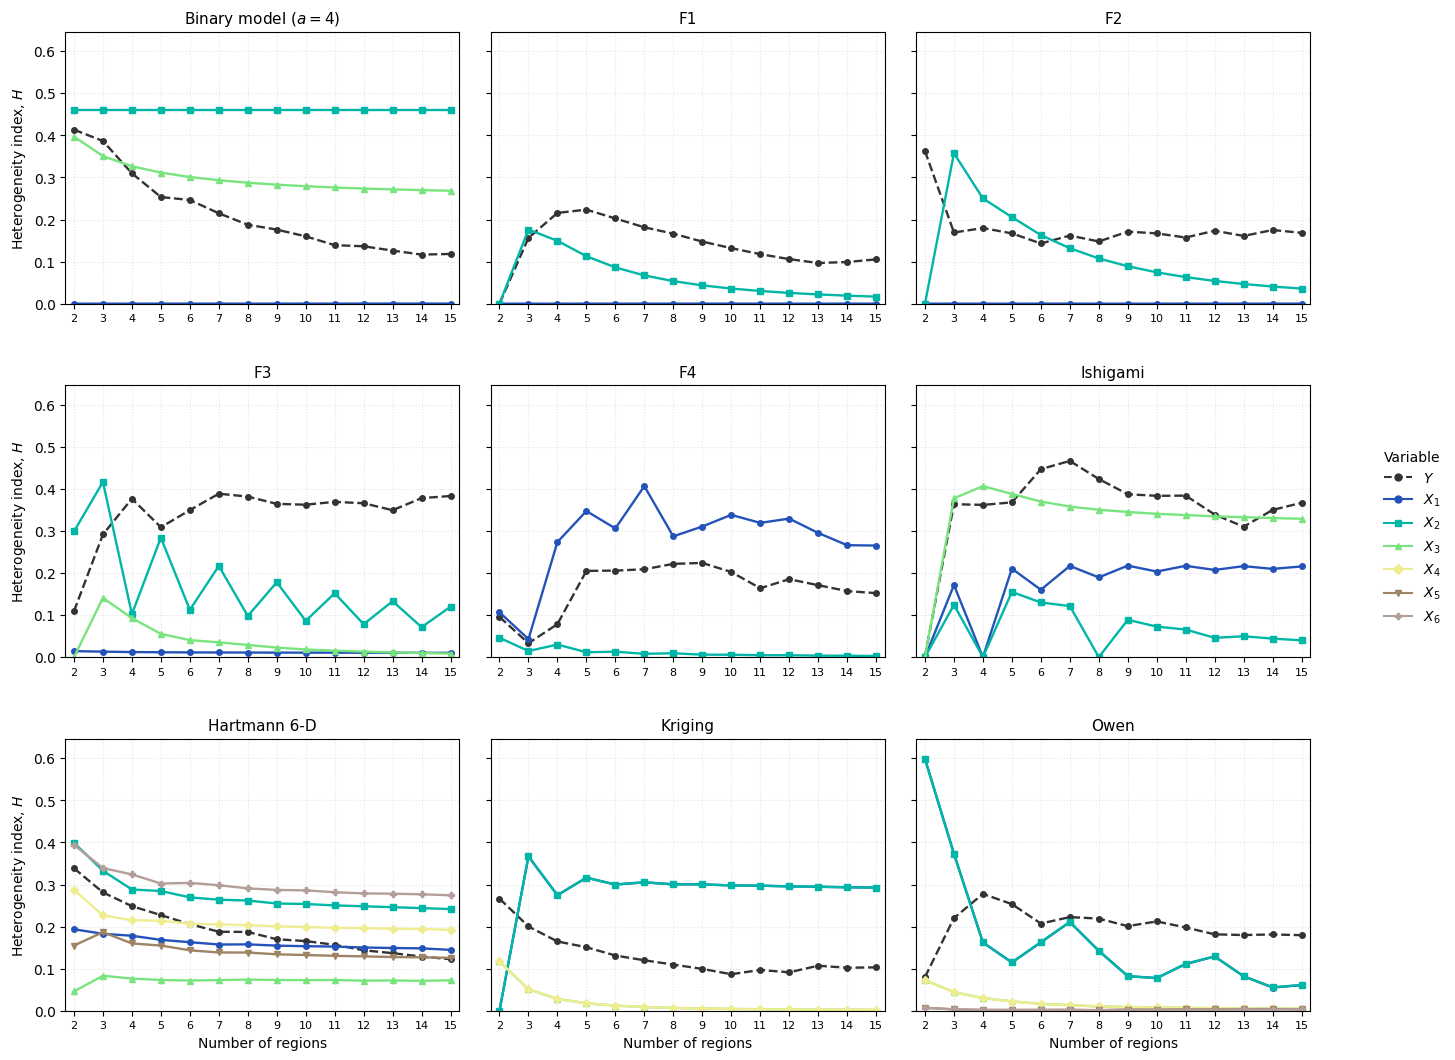

In [6]:
# Figure h3: H as a function of q.
fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True, sharey=True)
finite = q_results["H"].dropna()
ymax = max(0.05, 1.08 * finite.max())
for ax, name in zip(axes.flat, FUNCTION_NAMES):
    X, _ = DATA[name]
    for variable in ["Y", *X.columns]:
        frame = q_results.loc[(q_results["function"] == name) & (q_results["variable"] == variable) & q_results["q"].isin(Q_LINE)].sort_values("q")
        ax.plot(frame["q"], frame["H"], color=VARIABLE_COLORS[variable], linestyle="--" if variable == "Y" else "-", marker=VARIABLE_MARKERS[variable], markersize=4, linewidth=1.7)
    ax.set_title(FUNCTION_TITLES[name], fontsize=11)
    ax.set_xticks(Q_LINE)
    ax.tick_params(axis="x", labelsize=8, labelbottom=True)
    ax.grid(linestyle=":", alpha=0.35)
    ax.set_xlim(1.7, 15.3)
    ax.set_ylim(0, ymax)
for ax in axes[-1, :]:
    ax.set_xlabel("Number of regions")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Heterogeneity index, $H$")
handles = [Line2D([0], [0], color=VARIABLE_COLORS[v], linestyle="--" if v == "Y" else "-", marker=VARIABLE_MARKERS[v], label=variable_label(v), markersize=5) for v in ["Y", "X1", "X2", "X3", "X4", "X5", "X6"]]
fig.legend(handles=handles, title="Variable", loc="center right", bbox_to_anchor=(0.995, 0.5), frameon=False)
fig.subplots_adjust(left=0.07, right=0.90, bottom=0.07, top=0.96, wspace=0.08, hspace=0.30)
plt.show()

Figure 4: Sensitivity of the heterogeneity index 𝐻 to the number of regions across the nine test models. Each panel
shows 𝐻 obtained by conditioning on the output 𝑌 and on each model input

## Appendix 1. Regional sensitivity profiles across different numbers of regions

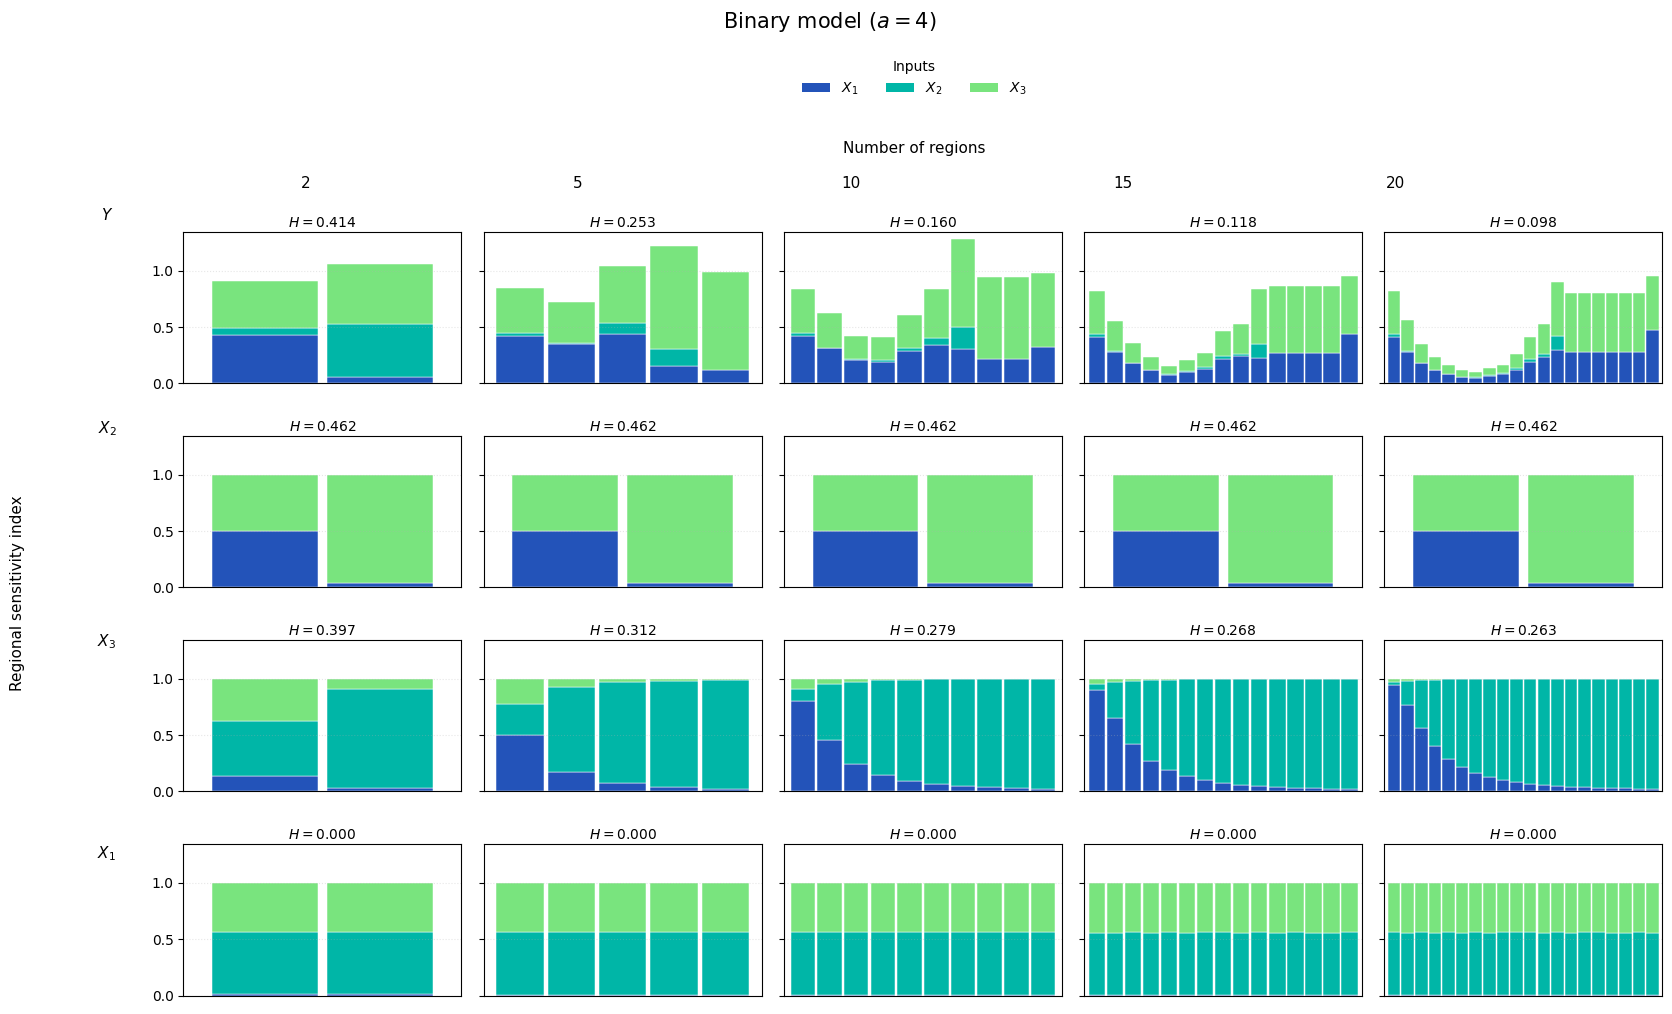

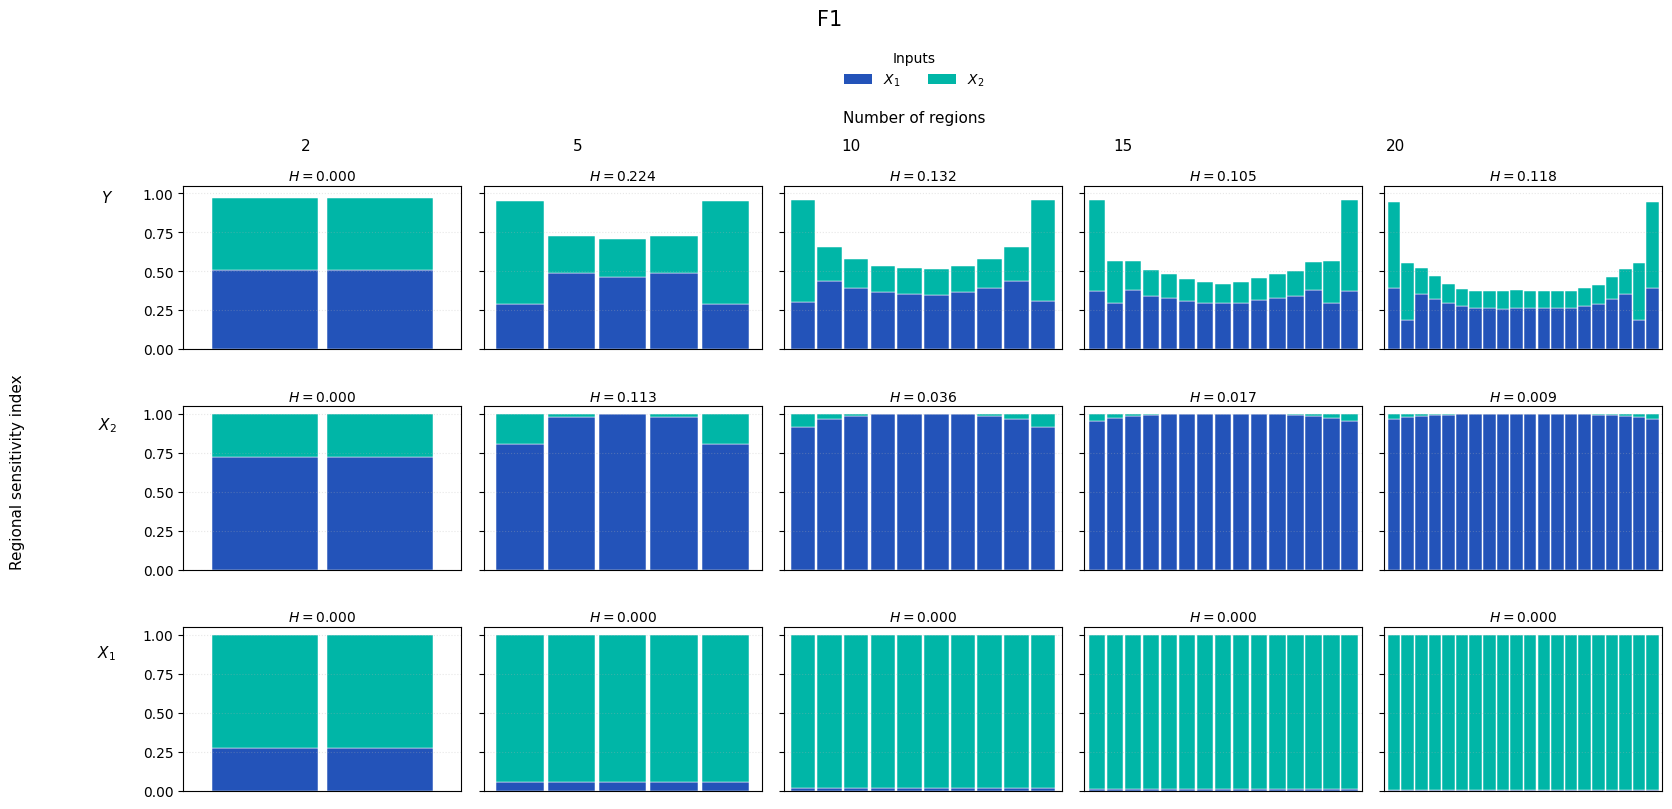

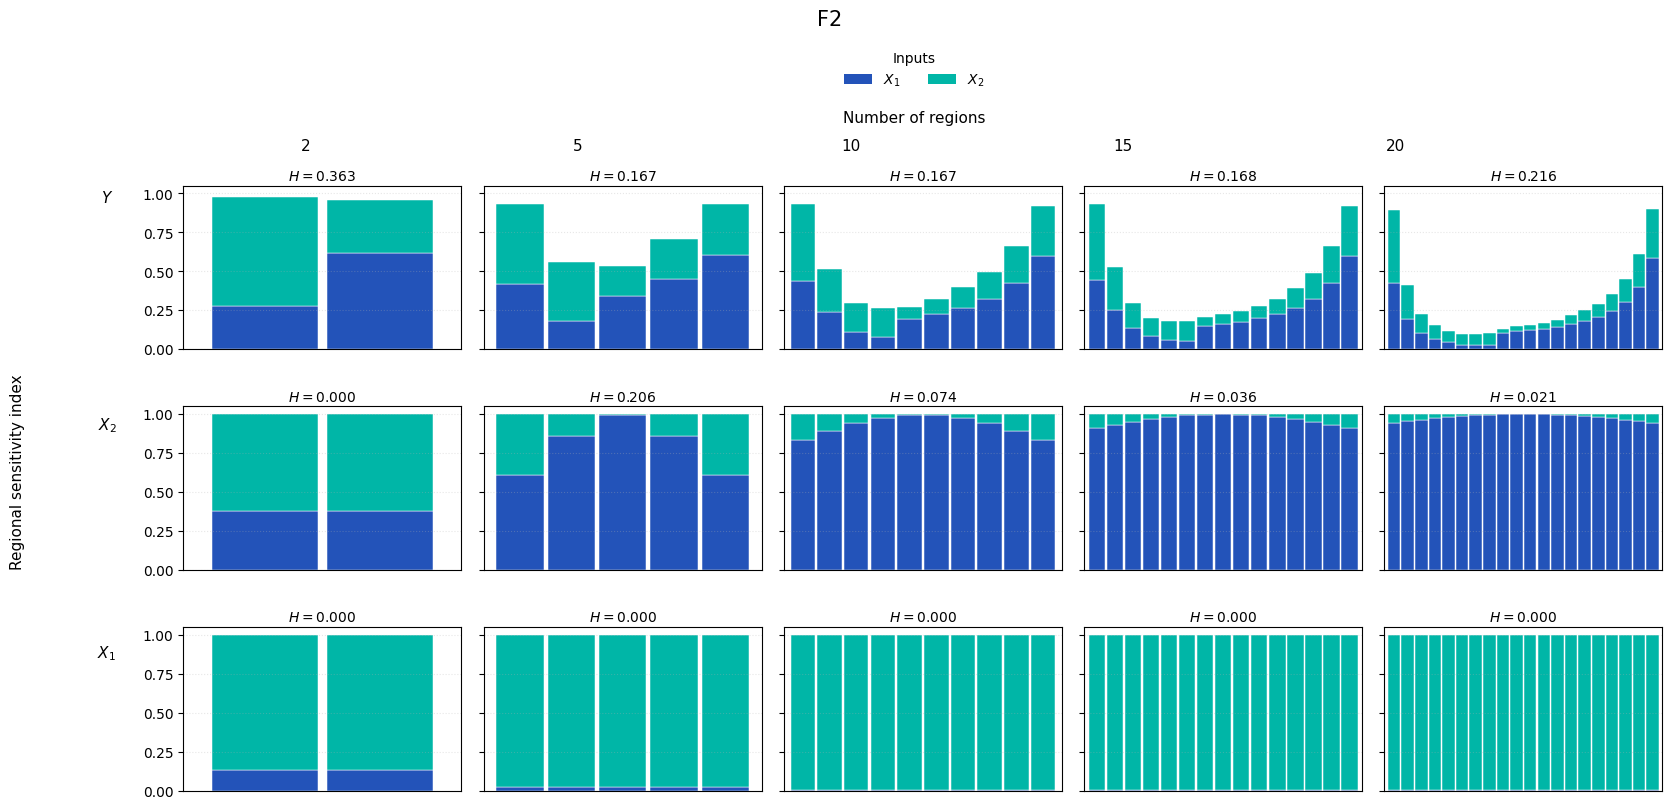

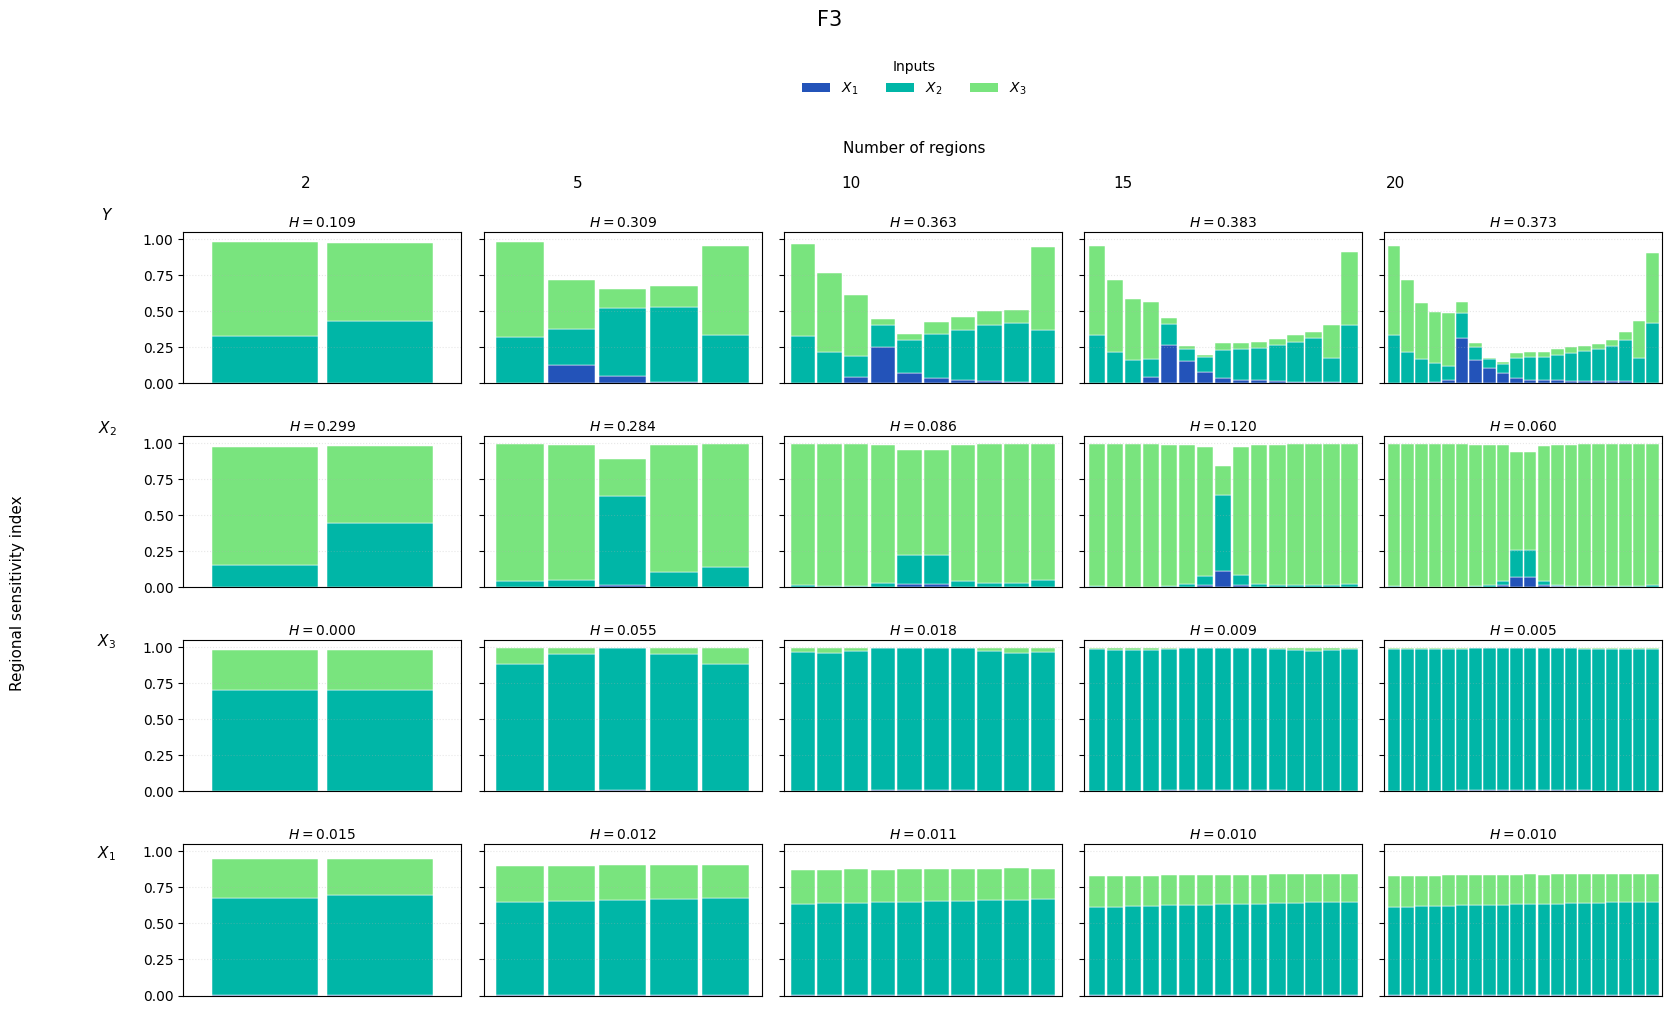

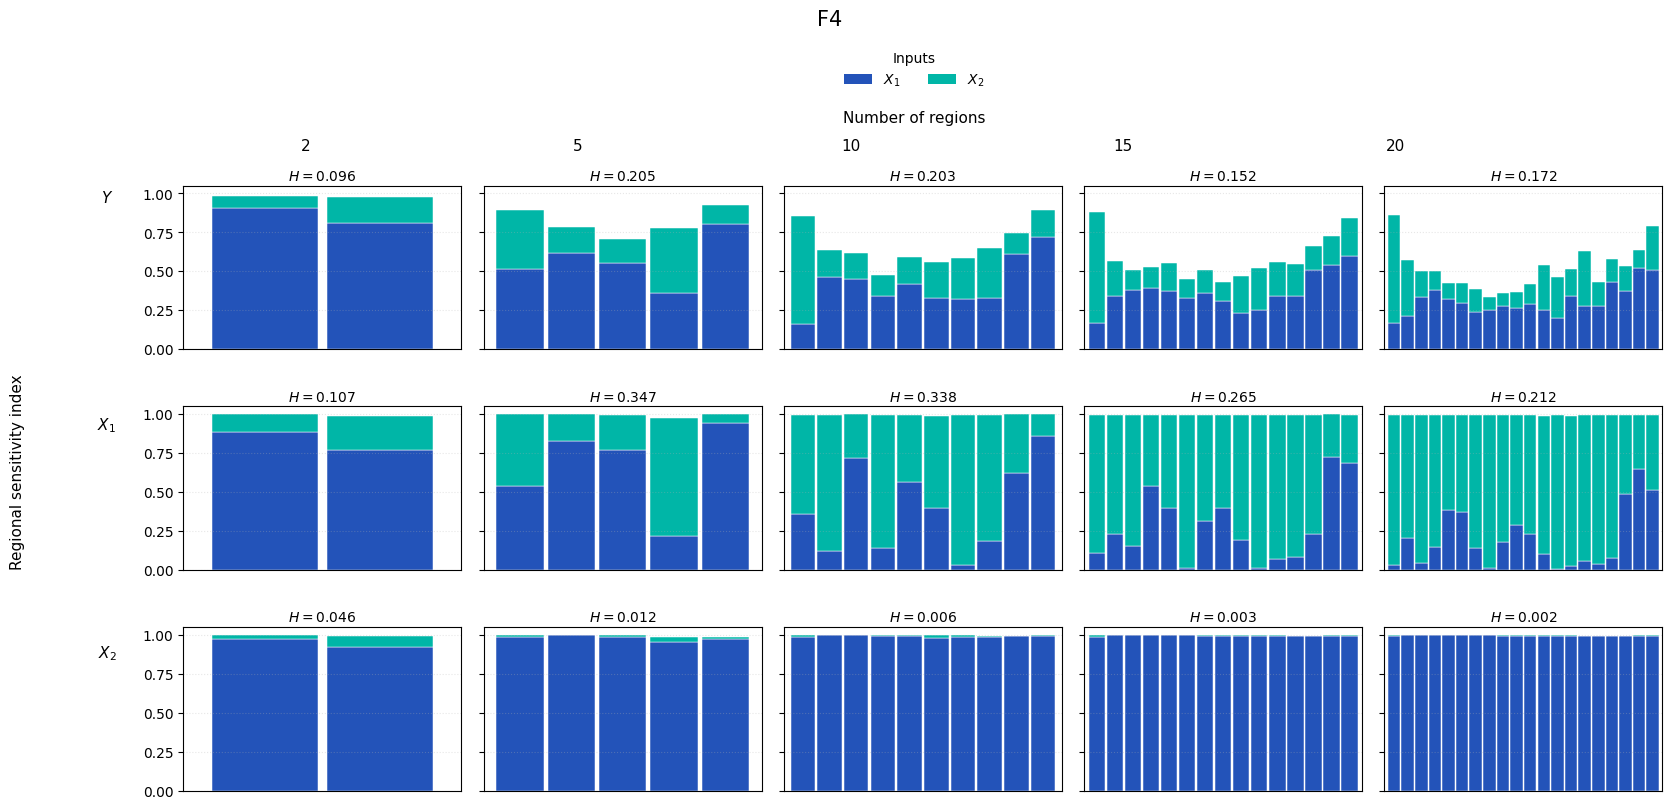

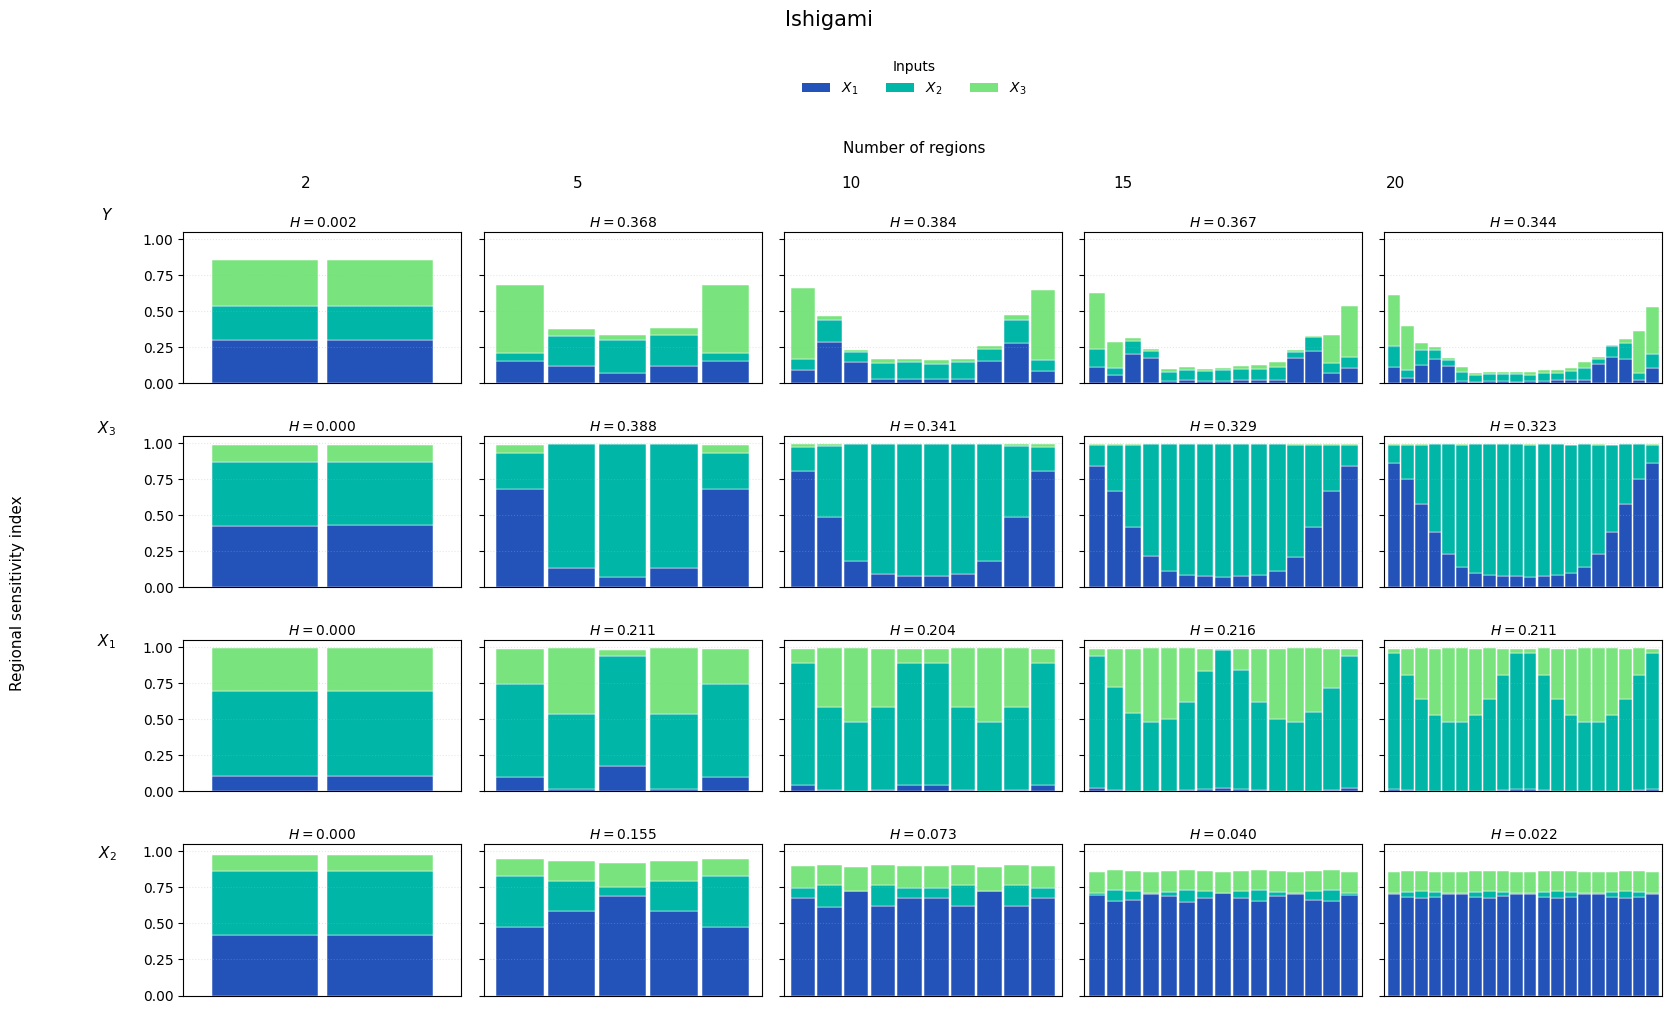

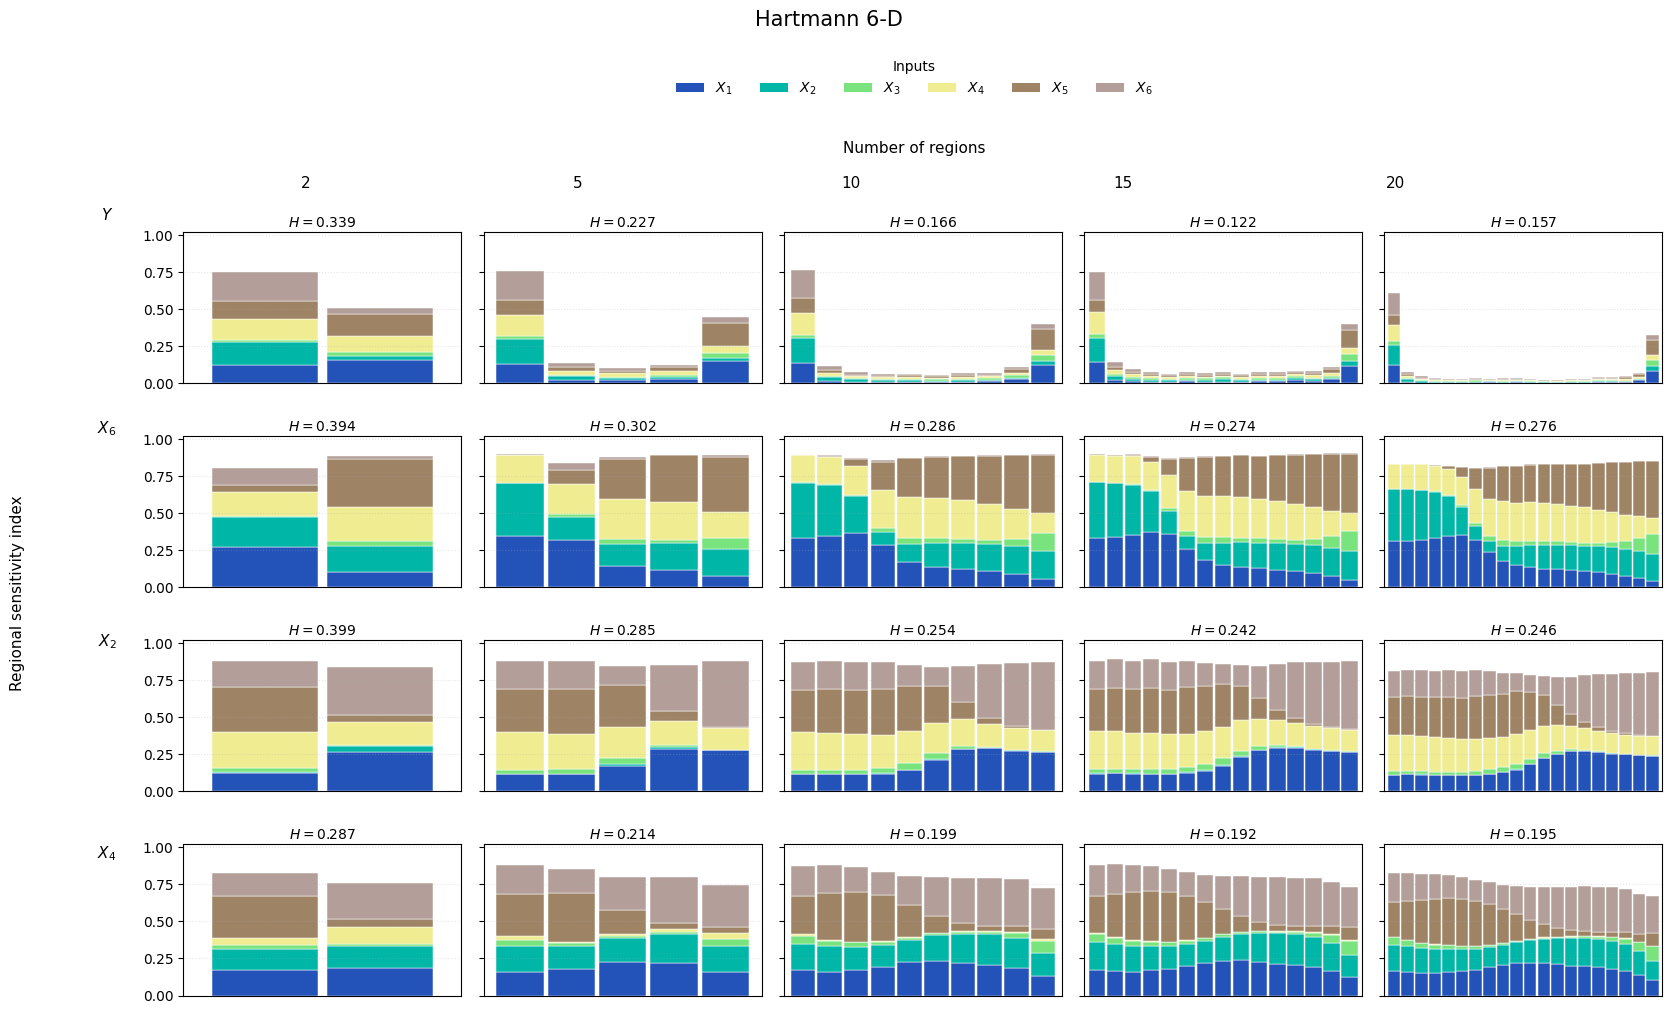

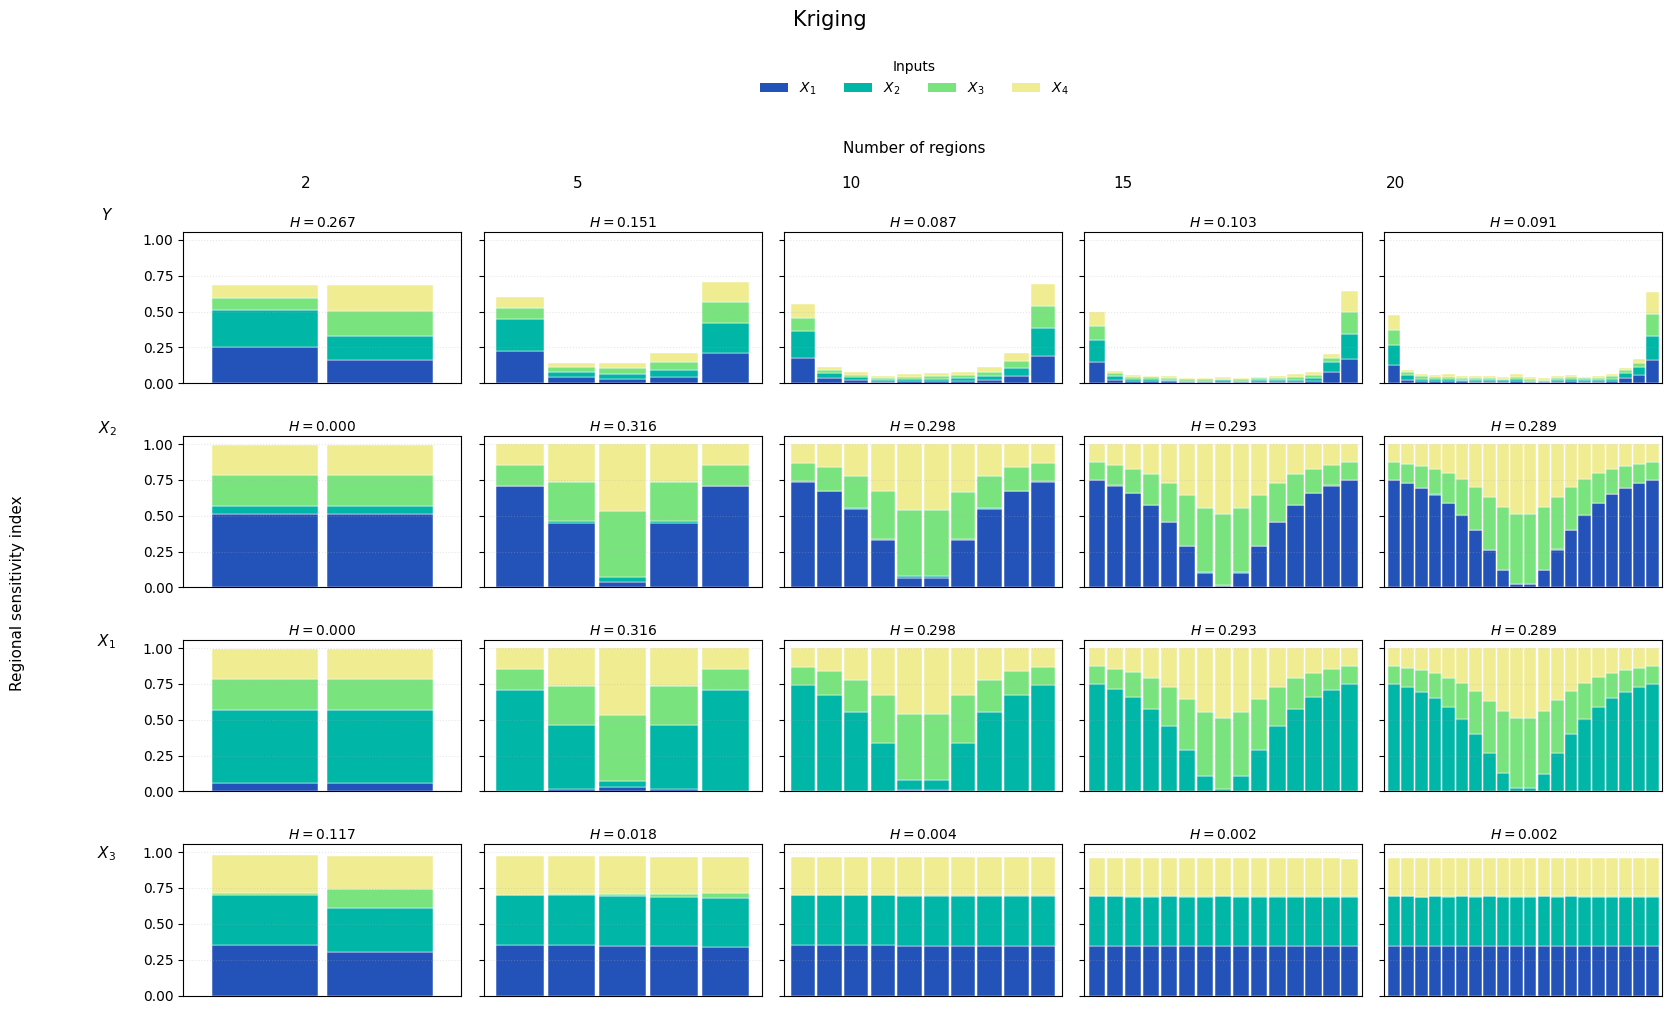

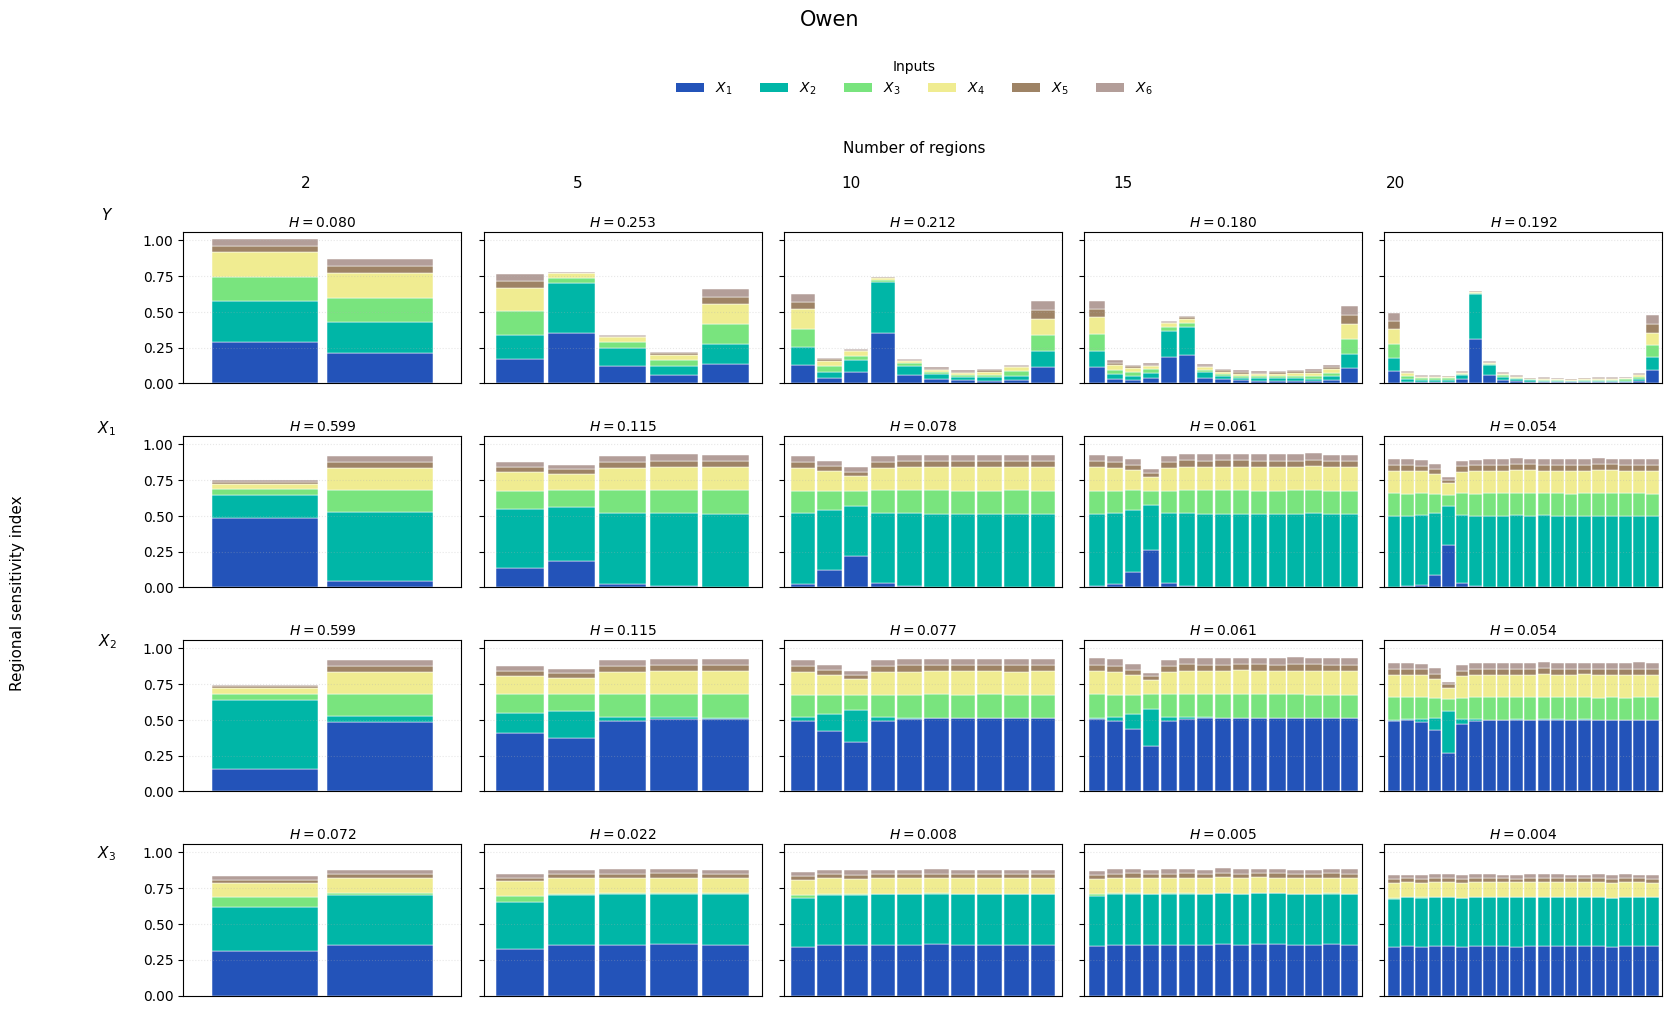

In [7]:
def plot_regional_grid(function_name):
    variables = ["Y", *TOP_INPUTS[function_name]]
    X, _ = DATA[function_name]
    fig, axes = plt.subplots(len(variables), len(Q_PROFILE), figsize=(17, 2.2 * len(variables) + 1.8), sharey=True, squeeze=False)

    totals = []
    for variable in variables:
        for q in Q_PROFILE:
            H = H_CACHE[(function_name, q)]
            if variable in H.details:
                totals.extend(H.details[variable].raw_profiles.sum(axis=1).to_numpy(float))
    ymax = max(1.02, 1.05 * max(totals)) if totals else 1.02

    for r, variable in enumerate(variables):
        for c, q in enumerate(Q_PROFILE):
            ax = axes[r, c]
            H = H_CACHE[(function_name, q)]
            if variable not in H.details:
                ax.text(0.5, 0.5, "not available", transform=ax.transAxes, ha="center", va="center")
                ax.set_xticks([])
                continue
            raw = H.details[variable].raw_profiles
            raw.plot(kind="bar", stacked=True, ax=ax, color=[VARIABLE_COLORS[col] for col in raw.columns], edgecolor="white", linewidth=0.35, width=0.92, legend=False)
            ax.set_title(rf"$H={H.indices[variable]:.3f}$", fontsize=10, pad=4)
            ax.set_ylim(0, ymax)
            ax.set_xticks([])
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.grid(axis="y", linestyle=":", alpha=0.30)

    fig.suptitle(FUNCTION_TITLES[function_name], y=0.99, fontsize=15)
    fig.legend(handles=[Patch(facecolor=VARIABLE_COLORS[v], label=variable_label(v)) for v in X.columns], title="Inputs", ncol=len(X.columns), loc="upper center", bbox_to_anchor=(0.55, 0.955), frameon=False)
    fig.text(0.55, 0.855, "Number of regions", ha="center", fontsize=11)
    for c, q in enumerate(Q_PROFILE):
        box = axes[0, c].get_position()
        fig.text((box.x0 + box.x1) / 2, 0.822, str(q), ha="center", fontsize=11)
    for r, variable in enumerate(variables):
        box = axes[r, 0].get_position()
        fig.text(0.075, (box.y0 + box.y1) / 2, variable_label(variable), ha="center", va="center", fontsize=11)
    fig.text(0.018, 0.44, "Regional sensitivity index", rotation=90, va="center", fontsize=11)
    fig.subplots_adjust(left=0.12, right=0.99, bottom=0.06, top=0.78, wspace=0.08, hspace=0.35)
    stem = function_name.lower().replace(" ", "_").replace("-", "_")
    plt.show()

for name in FUNCTION_NAMES:
    plot_regional_grid(name)